# Testando Perceptron com o Dataset Breast Cancer

O dataset Breast Cancer Wisconsin é um dos benchmarks mais utilizados
em classificação médica. Ele contém 569 amostras de tumores mamários,
cada uma descrita por **30 features numéricas** extraídas de imagens
de biópsias — como raio médio, textura, perímetro e concavidade das
células. O objetivo é classificar cada amostra em **maligno** (1) ou
**benigno** (0).

Diferente do Iris, aqui não precisamos filtrar classes nem escolher
features manualmente: o problema já é binário e usaremos todas as 30
dimensões para treinar o modelo.

Isso traz um desafio novo: com 30 features, não é possível visualizar
os dados diretamente em 2D. Para a análise exploratória, usaremos
**PCA** para reduzir as dimensões apenas na visualização — sem afetar
o treinamento, que continua com os dados completos.

## Dependências e Configurações

In [23]:
from perceptron import Perceptron 

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA

print(' - Bibliotecas carregadas com sucesso - ')

 - Bibliotecas carregadas com sucesso - 


## 1. Carregando os Dados

O sklearn já traz o Dataset Breast Cancer embutido, então não precisamos de download ou
leitura de arquivo. Vamos carregar e inspecionar a estrutura antes de
qualquer transformação — é sempre útil entender o que está nas mãos
antes de mexer.

In [2]:
data = load_breast_cancer()
x = data.data
y = data.target

print('Classes  :', data.target_names)
print('Features :', data.feature_names)

Classes  : ['malignant' 'benign']
Features : ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [4]:
x[:5], y[:5]

(array([[1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
         3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
         8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
         3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
         1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, 1.326e+03, 8.474e-02, 7.864e-02,
         8.690e-02, 7.017e-02, 1.812e-01, 5.667e-02, 5.435e-01, 7.339e-01,
         3.398e+00, 7.408e+01, 5.225e-03, 1.308e-02, 1.860e-02, 1.340e-02,
         1.389e-02, 3.532e-03, 2.499e+01, 2.341e+01, 1.588e+02, 1.956e+03,
         1.238e-01, 1.866e-01, 2.416e-01, 1.860e-01, 2.750e-01, 8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, 1.203e+03, 1.096e-01, 1.599e-01,
         1.974e-01, 1.279e-01, 2.069e-01, 5.999e-02, 7.456e-01, 7.869e-01,
         4.585e+00, 9.403e+01, 6.150e-03, 4.006e-02, 3.832e-02, 2.058e-02,
         2.250e-02, 4.5

In [5]:
print(f"Formato de X: {x.shape}")
print(f"Formato de y: {y.shape}")
print(f"Classes únicas em y: {np.unique(y)}")

Formato de X: (569, 30)
Formato de y: (569,)
Classes únicas em y: [0 1]


## 2. Preprocessamento

Com 30 features em escalas bastante diferentes — `mean area` pode
chegar a 2500, enquanto `mean smoothness` fica em torno de 0.1 — a
normalização é especialmente crítica aqui. Sem ela, as features de
maior magnitude dominam o aprendizado independentemente de sua
relevância real.

Não há filtragem de classes nem seleção de colunas: o dataset já está
no formato que precisamos.

### 2.1 Normalização

O Perceptron atualiza os pesos somando o erro multiplicado pelo valor
da feature. Se uma feature tem valores na casa de 5.0 e outra na casa
de 0.2, a primeira dominará as atualizações — não por ser mais
informativa, mas simplesmente por ser maior.

O `StandardScaler` corrige isso: transforma cada feature para ter
**média 0 e desvio padrão 1**, colocando todas na mesma escala e
tornando o aprendizado mais estável.

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(x)
X[:5]

array([[ 1.09706398e+00, -2.07333501e+00,  1.26993369e+00,
         9.84374905e-01,  1.56846633e+00,  3.28351467e+00,
         2.65287398e+00,  2.53247522e+00,  2.21751501e+00,
         2.25574689e+00,  2.48973393e+00, -5.65265059e-01,
         2.83303087e+00,  2.48757756e+00, -2.14001647e-01,
         1.31686157e+00,  7.24026158e-01,  6.60819941e-01,
         1.14875667e+00,  9.07083081e-01,  1.88668963e+00,
        -1.35929347e+00,  2.30360062e+00,  2.00123749e+00,
         1.30768627e+00,  2.61666502e+00,  2.10952635e+00,
         2.29607613e+00,  2.75062224e+00,  1.93701461e+00],
       [ 1.82982061e+00, -3.53632408e-01,  1.68595471e+00,
         1.90870825e+00, -8.26962447e-01, -4.87071673e-01,
        -2.38458552e-02,  5.48144156e-01,  1.39236330e-03,
        -8.68652457e-01,  4.99254601e-01, -8.76243603e-01,
         2.63326966e-01,  7.42401948e-01, -6.05350847e-01,
        -6.92926270e-01, -4.40780058e-01,  2.60162067e-01,
        -8.05450380e-01, -9.94437403e-02,  1.80592744e+

In [7]:
print(f'Formato de X: {X.shape}')

Formato de X: (569, 30)


### 2.2 Divisão Treino / Teste

Separamos 80% dos dados para treino e 20% para teste. O modelo aprende
apenas com o conjunto de treino — o conjunto de teste fica "escondido"
e serve exclusivamente para medir como o modelo se comporta em dados
que nunca viu. Isso é o que nos dá uma estimativa honesta de
generalização.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

## 3. Análise Exploratória

Com 30 features, não é possível visualizar a separação entre classes
diretamente. Usamos **PCA (Principal Component Analysis)** para
projetar os dados nas duas direções de maior variância, criando uma
representação 2D que preserva a estrutura global do dataset.

É importante deixar claro: o PCA aqui é **apenas para visualização**.
O modelo será treinado com todas as 30 features originais — a
compressão serve só para termos uma ideia visual de quão separáveis
os grupos são no espaço de alta dimensão.

Se os dois grupos aparecerem relativamente separados na projeção PCA,
isso é um indicativo favorável para a convergência do Perceptron.

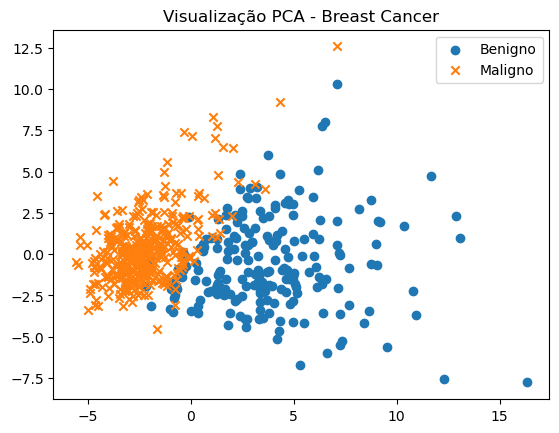

In [24]:
#PCA para visualização
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X)  

plt.scatter(X_vis[y==0, 0], X_vis[y==0, 1], label='Benigno', marker='o')
plt.scatter(X_vis[y==1, 0], X_vis[y==1, 1], label='Maligno', marker='x')
plt.title('Visualização PCA - Breast Cancer')
plt.legend()
plt.show()

## 4. Treinamento do Modelo

Com os dados preparados, agora treinamos o Perceptron. O algoritmo
percorre o conjunto de treino por `epochs` iterações completas. Em
cada amostra, ele faz uma previsão, calcula o erro e ajusta os pesos
na direção correta — o processo central da **Regra de Aprendizado do
Perceptron**.

Usamos `verbose=True` para acompanhar a evolução época a época: se
o número de erros cair progressivamente até zero (ou próximo disso),
o modelo está convergindo.

In [26]:
#instanciando o modelo
model = Perceptron(
    learning_rate=0.1, 
    epochs=1000, 
    verbose=True, 
    log_every=100, 
    random_state=42
)

#treinando o modelo
model.fit(X_train, y_train)

Época:    1/1000 | Erros:  24 | Acurácia:  95.82% | Bias:   0.2000
Época:  100/1000 | Erros:   7 | Acurácia:  98.90% | Bias:  -0.6000
Época:  200/1000 | Erros:  10 | Acurácia:  98.90% | Bias:  -1.0000
Época:  300/1000 | Erros:  11 | Acurácia:  99.34% | Bias:  -1.0000
Época:  400/1000 | Erros:   6 | Acurácia:  98.68% | Bias:  -1.1000
Época:  500/1000 | Erros:   7 | Acurácia:  99.34% | Bias:  -1.2000
Época:  600/1000 | Erros:   8 | Acurácia:  99.12% | Bias:  -1.6000

Convergência alcançada na época 687.


## 5. Avaliação

Com o modelo treinado, avaliamos em três frentes:

**Acurácia** — proporção de acertos no treino e no teste. Acurácias
próximas entre si indicam que o modelo generalizou bem, sem decorar
os dados de treino.

**Curva de aprendizado** — mostra como erros e acurácia evoluíram ao
longo das 1000 épocas. Com um problema de 30 dimensões, o Perceptron
pode precisar de mais iterações para convergir do que no Iris —
acompanhar essa curva revela se o modelo estabilizou ou ainda
oscilava ao final do treino.

**Matriz de confusão** — detalha os tipos de erro: quantos tumores
benignos foram classificados como malignos e vice-versa. Neste
contexto médico, os erros **não têm o mesmo peso**: um falso negativo
(maligno classificado como benigno) é clinicamente mais grave do que
um falso positivo.

In [27]:
#acuracia final
acuracia_treino = model.score(X_train, y_train)
acuracia_teste  = model.score(X_test, y_test)

print(f"Acurácia do modelo no Treino: {acuracia_treino:.2%}")
print(f"Acurácia do modelo no Teste : {acuracia_teste:.2%}")

Acurácia do modelo no Treino: 100.00%
Acurácia do modelo no Teste : 92.98%


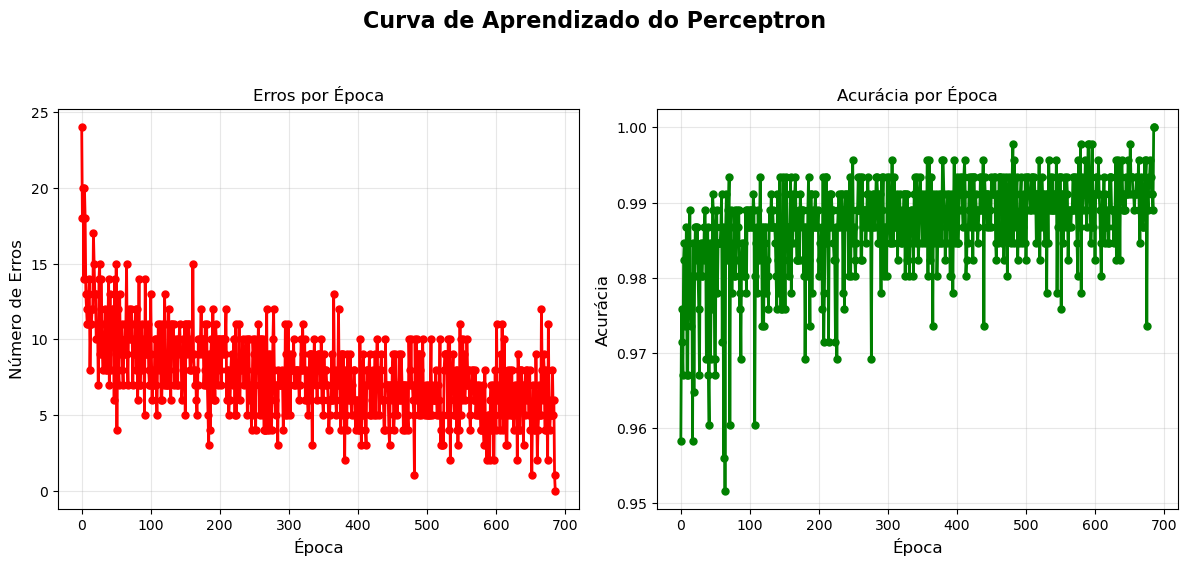

In [31]:
#curva de aprendizado
plt.figure(figsize=(12, 5))

#erros por epoca
plt.subplot(1, 2, 1)
plt.plot(model.errors, marker='o', color='red', linewidth=2, markersize=5)
plt.title('Erros por Época')
plt.xlabel('Época', fontsize=12)
plt.ylabel('Número de Erros', fontsize=12)
plt.grid(True, alpha=0.3)

#acuracia por epoca
plt.subplot(1, 2, 2)
plt.plot(model.accuracy_history, marker='o', color='green', linewidth=2, markersize=5)
plt.title('Acurácia por Época')
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Curva de Aprendizado do Perceptron', fontsize=16, fontweight='bold', y=1.1, verticalalignment='center', )
plt.show()

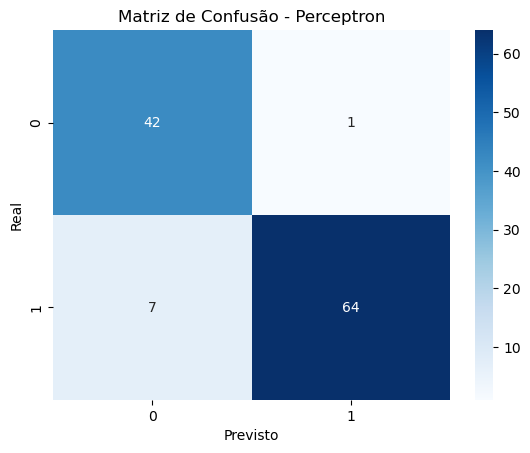

In [29]:
#matriz de confusao
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão - Perceptron")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

In [30]:
#relatorio
print(classification_report(y_test, y_pred) )

              precision    recall  f1-score   support

           0       0.86      0.98      0.91        43
           1       0.98      0.90      0.94        71

    accuracy                           0.93       114
   macro avg       0.92      0.94      0.93       114
weighted avg       0.94      0.93      0.93       114



## Conclusão e Considerações Finais

O Perceptron demonstrou capacidade de generalização razoável para este
problema, considerando que opera com um modelo linear simples sobre 30
features simultâneas.

Diferente do experimento com o Iris, aqui a separabilidade linear não
é garantida: tumores malignos e benignos podem se sobrepor em certas
regiões do espaço de features. Isso explica o uso de 1000 épocas —
muito mais do que as 50 do Iris — e pode se refletir em erros
residuais na curva de aprendizado.

Limitações que vale registrar:
- O Perceptron não produz probabilidades, apenas decisões binárias —
  o que reduz sua utilidade clínica real
- Em dados não linearmente separáveis, ele não converge para zero
  erros, independente do número de épocas
- Para aplicações médicas reais, modelos como Regressão Logística ou
  SVM oferecem melhor calibração e interpretabilidade

Do ponto de vista do portfolio, este experimento complementa o Iris
mostrando o Perceptron em um cenário mais desafiador: mais features,
mais épocas e consequências assimétricas dos erros.